# ⏱️ ESG Time Series Forecasting
**Objective:** Forecast GrowthRate, Revenue, and ESG_Overall for 2026–2030.

**Methods:** SARIMA (statsmodels) & Prophet (Facebook)

**Evaluation:** MAPE and RMSE

---

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Prophet
from prophet import Prophet

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

## 2. Load & Prepare Time Series Data

In [3]:
df = pd.read_csv('data/esg_processed.csv', index_col=0)
df.head()

,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption,ESG_Category
CompanyID,,,,,,,,,,,,,,,,
1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7,Good
1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4,Good
1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9,Good
1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2,Good
1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8,Good


In [4]:
# Aggregate to annual mean across all companies
METRICS = ['GrowthRate', 'Revenue', 'ESG_Overall']
ts_df = df.groupby('Year')[METRICS].mean().reset_index()
ts_df = ts_df.sort_values('Year').reset_index(drop=True)

print('Annual aggregated time series:')
ts_df

Annual aggregated time series:


,Year,GrowthRate,Revenue,ESG_Overall
0,2015,NaN,3305.8405,51.4419
1,2016,4.8187,3478.7087,52.0439
2,2017,5.2290,3705.9681,52.6777
3,2018,4.6747,3942.4906,53.3514
4,2019,4.8337,4214.2729,53.9070
5,2020,4.7114,4494.4549,54.5884
6,2021,4.6917,4818.3895,55.2397
7,2022,4.8097,5173.3626,55.9208
8,2023,4.7904,5599.7921,56.5865
9,2024,5.1391,6063.9399,57.1767


In [5]:
fig = make_subplots(rows=3, cols=1, subplot_titles=METRICS, shared_xaxes=True)
colors = ['#3498db', '#2ecc71', '#e67e22']

for i, (metric, color) in enumerate(zip(METRICS, colors), 1):
 fig.add_trace(go.Scatter(x=ts_df['Year'], y=ts_df[metric],
 mode='lines+markers', name=metric, line=dict(color=color, width=2)),
 row=i, col=1)

fig.update_layout(title='Historical Trends (2015–2025)', height=600, showlegend=True)
fig.show()

## 3. Stationarity Check (ADF Test)

In [6]:
def adf_test(series, name):
 result = adfuller(series.dropna())
 print(f'{name}:')
 print(f' ADF Statistic : {result[0]:.4f}')
 print(f' p-value : {result[1]:.4f}')
 print(f' Stationary : {"Yes" if result[1] < 0.05 else "No (differencing needed)"}')
 print()

for metric in METRICS:
 adf_test(ts_df[metric], metric)

GrowthRate:
 ADF Statistic : -3.7468
 p-value : 0.0035
 Stationary : Yes

Revenue:
 ADF Statistic : 5.6138
 p-value : 1.0000
 Stationary : No (differencing needed)

ESG_Overall:
 ADF Statistic : 0.5784
 p-value : 0.9871
 Stationary : No (differencing needed)



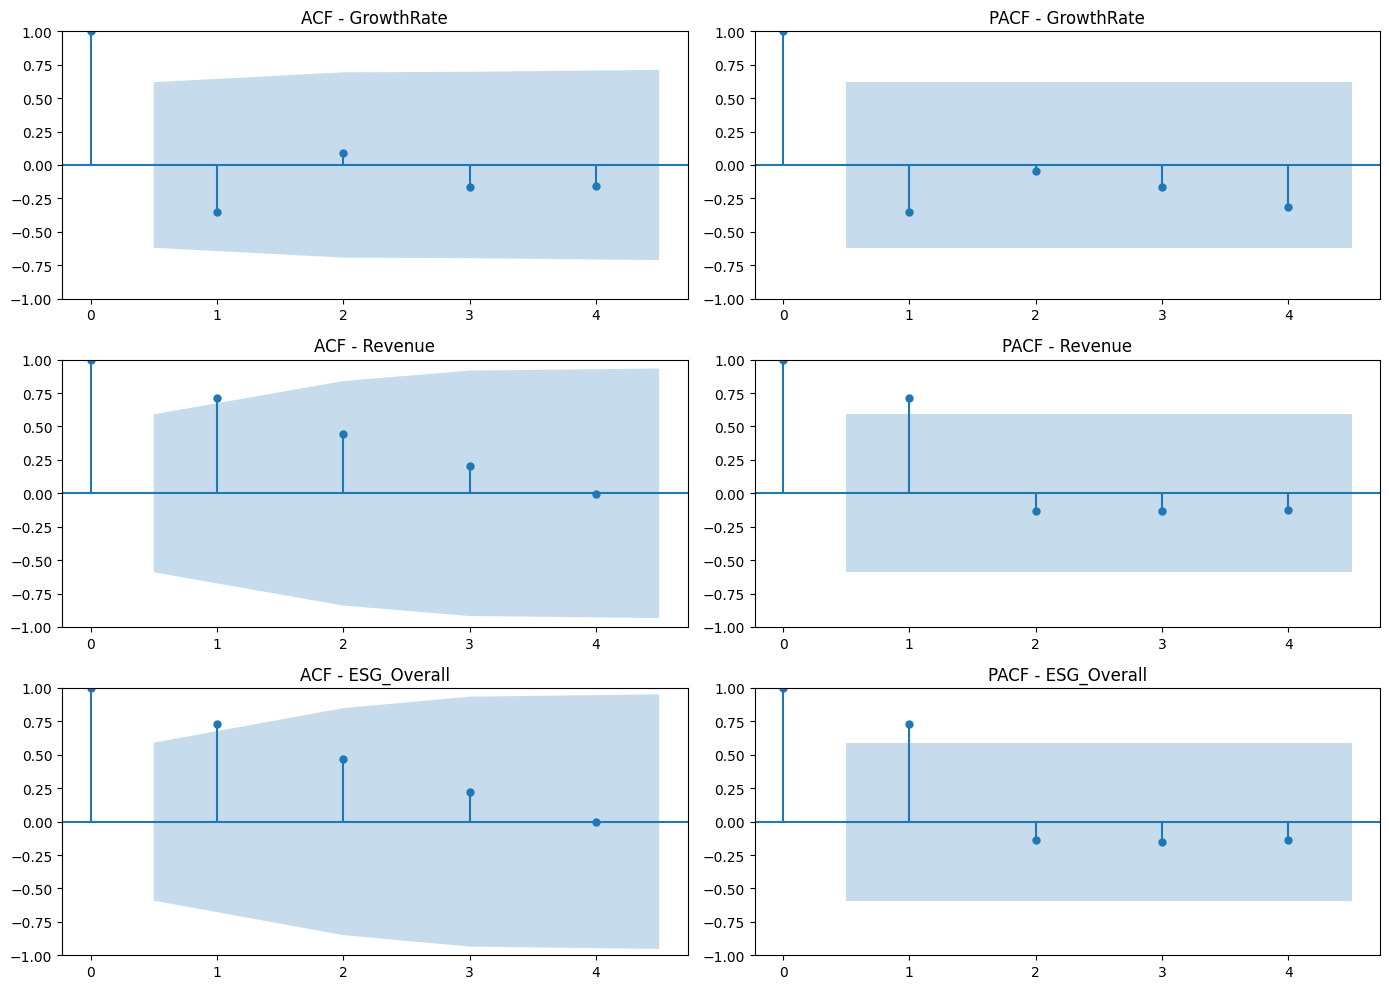

In [8]:
fig, axes = plt.subplots(len(METRICS), 2, figsize=(14, 10))

for i, metric in enumerate(METRICS):
 series = ts_df[metric].dropna()
 plot_acf(series, ax=axes[i, 0], lags=min(8, len(series)//2 - 1), title=f'ACF - {metric}')
 plot_pacf(series, ax=axes[i, 1], lags=min(8, len(series)//2 - 1), title=f'PACF - {metric}')

plt.tight_layout()
plt.show()

## 4. Train-Test Split for Evaluation

In [9]:
# Use 2015-2022 for training, 2023-2025 for testing
TRAIN_END = 2022
TEST_START = 2023
FORECAST_YEARS = list(range(2026, 2031))

ts_train = ts_df[ts_df['Year'] <= TRAIN_END].copy()
ts_test = ts_df[ts_df['Year'] >= TEST_START].copy()

print(f'Train: {ts_train["Year"].min()} - {ts_train["Year"].max()} ({len(ts_train)} years)')
print(f'Test : {ts_test["Year"].min()} - {ts_test["Year"].max()} ({len(ts_test)} years)')
print(f'Forecast: {FORECAST_YEARS}')

Train: 2015 - 2022 (8 years)
Test : 2023 - 2025 (3 years)
Forecast: [2026, 2027, 2028, 2029, 2030]


## 5. SARIMA Forecasting

In [14]:
sarima_results = {}
sarima_forecasts = {}

# SARIMA order — annual data, no strong seasonality (s=1)
SARIMA_ORDER = (1, 1, 1)
SARIMA_SEASONAL = (0, 0, 0, 0)

for metric in METRICS:
 print(f'Fitting SARIMA for {metric}...')
 train_series = ts_train[metric].values
 test_series = ts_test[metric].values
 n_test = len(test_series)

 model = SARIMAX(train_series, order=SARIMA_ORDER,
 seasonal_order=SARIMA_SEASONAL,
 enforce_stationarity=False,
 enforce_invertibility=False)
 fit = model.fit(disp=False, method='nm', maxiter=200)

 # Predict on test set
 test_pred = fit.forecast(steps=n_test)

 # Forecast future (2026-2030) — refit on full data
 full_model = SARIMAX(ts_df[metric].values, order=SARIMA_ORDER,
 seasonal_order=SARIMA_SEASONAL,
 enforce_stationarity=False,
 enforce_invertibility=False)
 full_fit = full_model.fit(disp=False, maxiter=200)
 future_pred = full_fit.forecast(steps=5)

 rmse = np.sqrt(mean_squared_error(test_series, test_pred))
 mape = mean_absolute_percentage_error(test_series, test_pred) * 100

 sarima_results[metric] = {'RMSE': rmse, 'MAPE': mape}
 sarima_forecasts[metric] = future_pred
 print(f' RMSE={rmse:.4f} | MAPE={mape:.2f}%')

Fitting SARIMA for GrowthRate...
 RMSE=0.2317 | MAPE=4.35%
Fitting SARIMA for Revenue...
 RMSE=67.3059 | MAPE=1.00%
Fitting SARIMA for ESG_Overall...
 RMSE=0.1087 | MAPE=0.16%


## 6. Model & Forecast Visualization

In [21]:
comparison_rows = []
for metric in METRICS:
 comparison_rows.append({
 'Metric': metric,
 'SARIMA_RMSE': sarima_results[metric]['RMSE'],
 'SARIMA_MAPE': sarima_results[metric]['MAPE']
 })

comparison_df = pd.DataFrame(comparison_rows)
print('SARIMA Metrics:')
comparison_df
comparison_df

SARIMA Metrics:


,Metric,SARIMA_RMSE,SARIMA_MAPE
0,GrowthRate,0.231717,4.345488
1,Revenue,67.305941,1.001551
2,ESG_Overall,0.108684,0.159379


In [23]:
for metric in METRICS:
 fig = go.Figure()

 # Historical
 fig.add_trace(go.Scatter(x=ts_df['Year'], y=ts_df[metric],
 mode='lines+markers', name='Historical',
 line=dict(color='#2c3e50', width=2)))

 # SARIMA Forecast
 fig.add_trace(go.Scatter(x=FORECAST_YEARS, y=sarima_forecasts[metric],
 mode='lines+markers', name='SARIMA Forecast',
 line=dict(color='#e74c3c', dash='dash', width=2)))

 fig.add_vline(x=2025.5, line_dash='dash', line_color='gray',
 annotation_text='Forecast Start')

 fig.update_layout(
 title=f'{metric} Forecast 2026–2030',
 xaxis_title='Year', yaxis_title=metric,
 legend=dict(orientation='h', yanchor='bottom', y=1.02),
 height=450
 )
 fig.show()

## 8. Save Forecast Results

In [25]:
forecast_rows = []
for year_idx, year in enumerate(FORECAST_YEARS):
 row = {'Year': year}
 for metric in METRICS:
  row[f'{metric}_SARIMA'] = sarima_forecasts[metric][year_idx]
  forecast_rows.append(row)

In [26]:
forecast_df = pd.DataFrame(forecast_rows)
forecast_df

,Year,GrowthRate_SARIMA,Revenue_SARIMA,ESG_Overall_SARIMA
0,2026,5.039551,7162.326314,58.487991
1,2026,5.039551,7162.326314,58.487991
2,2026,5.039551,7162.326314,58.487991
3,2027,4.686690,7812.210464,59.144712
4,2027,4.686690,7812.210464,59.144712
5,2027,4.686690,7812.210464,59.144712
6,2028,4.973416,8540.161117,59.804175
7,2028,4.973416,8540.161117,59.804175
8,2028,4.973416,8540.161117,59.804175
9,2029,4.740430,9355.555910,60.466391


In [27]:
forecast_df.to_csv('forecast.csv', index=False)

## 9. Key Findings

- GrowthRate:

SARIMA MAPE : 4.35%

- Revenue:

SARIMA MAPE : 1.00%

- ESG_Overall:

SARIMA MAPE : 0.16%